In [1]:
import os
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from plotUtils import *
from connectivity import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
# Vectorized euler intergration implementation

def euler_intergrate(u, init_point, modNodes,  **opts):
    # common parameters
    beta = opts.get('beta')
    gamma = opts.get('gamma')
    theta = opts.get('theta')

    nTrials, N = init_point.shape
    nNodes = N // 2

    for q in range(nTrials):
        u[q, :, 0] = init_point[q, :]       # initializing membrane potentials
        
        for t in range(opts.get('T') - 1):
            Fvect = np.zeros((2 * nNodes, 1))
            Imod = np.zeros((2 * nNodes, 1))

            for n in range(nNodes):
                Fvect[2 * n] = F(u[q, 2 * n, t], beta, theta, gamma, opts.get('sigma')[2 * n])
                Fvect[2 * n + 1] = F(u[q, 2 * n + 1, t], beta, theta, gamma, opts.get('sigma')[2 * n + 1])

                Imod[2 * n] = opts.get('i_mod') if n in modNodes else 0

            uVect = -u[q, :, t].reshape(-1, 1) + opts.get('W') @ Fvect + opts.get('Kglob') * opts.get('Abar') @ u[q, :, t].reshape(-1, 1) + opts.get('i_bias') + Imod
            uVect = opts.get('dt') * opts.get('Tau') @ uVect
            u[q, :, t + 1] = u[q, :, t] + uVect.flatten()           # updating membrane potentials
            
    return u

In [3]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
nTrials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

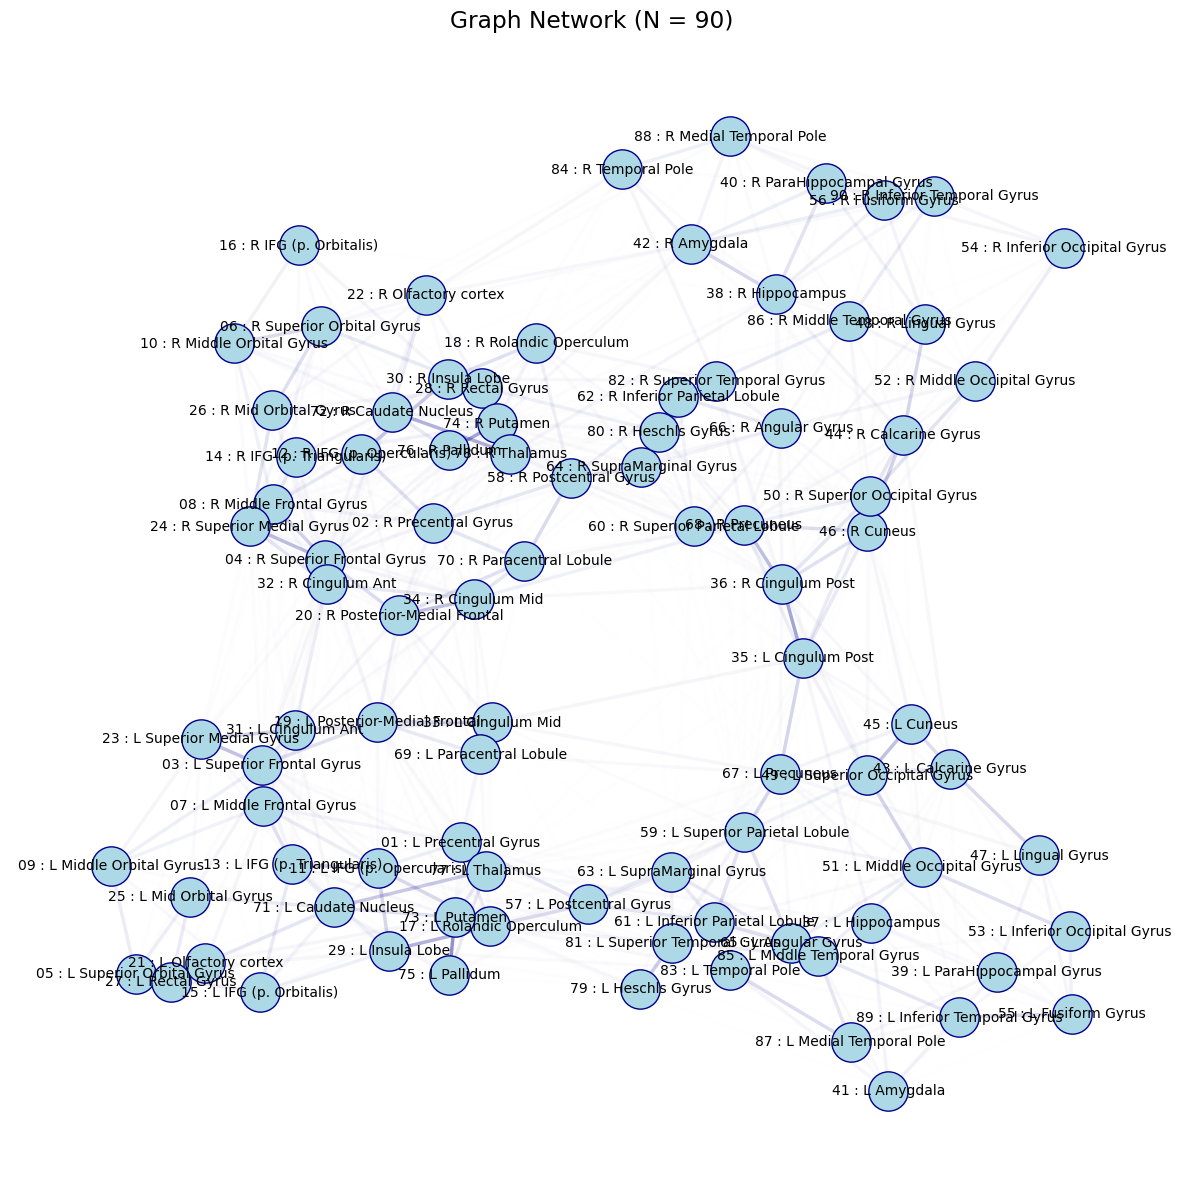

In [4]:
# Reading connectivity matrix from OSF data

AALMAp = pd.read_csv("./AAL_regions.csv", sep=";")
ROI = AALMAp['ROI number'].to_numpy()


ROI_tags = AALMAp['ROI name'].to_numpy()

A = pd.read_csv("./S001.csv", header=None).to_numpy()
A = (A + A.T) / 2

nNodes = A.shape[0]    # Network size

G = nx.from_numpy_array(A, parallel_edges=False)
plot_weighted_graph(G = G, N = nNodes, ROI_no=ROI, ROI_tags=ROI_tags, ifSave = False, savePath='', figsize = (15, 15))

(0.0, 0.41840882835)

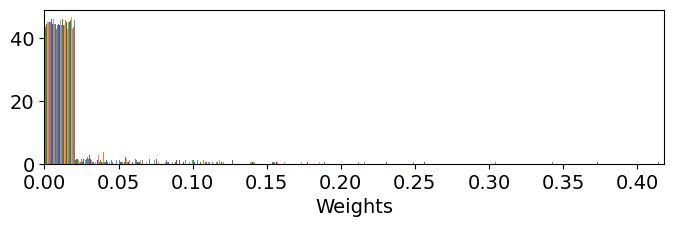

In [5]:
# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(A, bins=20, density=True, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(A), np.max(A))

In [6]:
# creating a sub graph from right hemisphere ROIs

RightROIs = ROI[1 :: 2] - 1
params['N'] = nNodes = 10

RandomROIS = RightROIs[15 : 15 + nNodes] # np.array(random.sample(list(RightROIs), k=nNodes))
RandomROI_tags = ROI_tags[RandomROIS]
ASubgraph = A[RandomROIS, :][:, RandomROIS]

# Scaling
normalization_factor = np.max(np.abs(ASubgraph.sum(axis=1)))
ASubgraph /= normalization_factor

Text(0.5, 1.0, 'Graph Network (N = 10)')

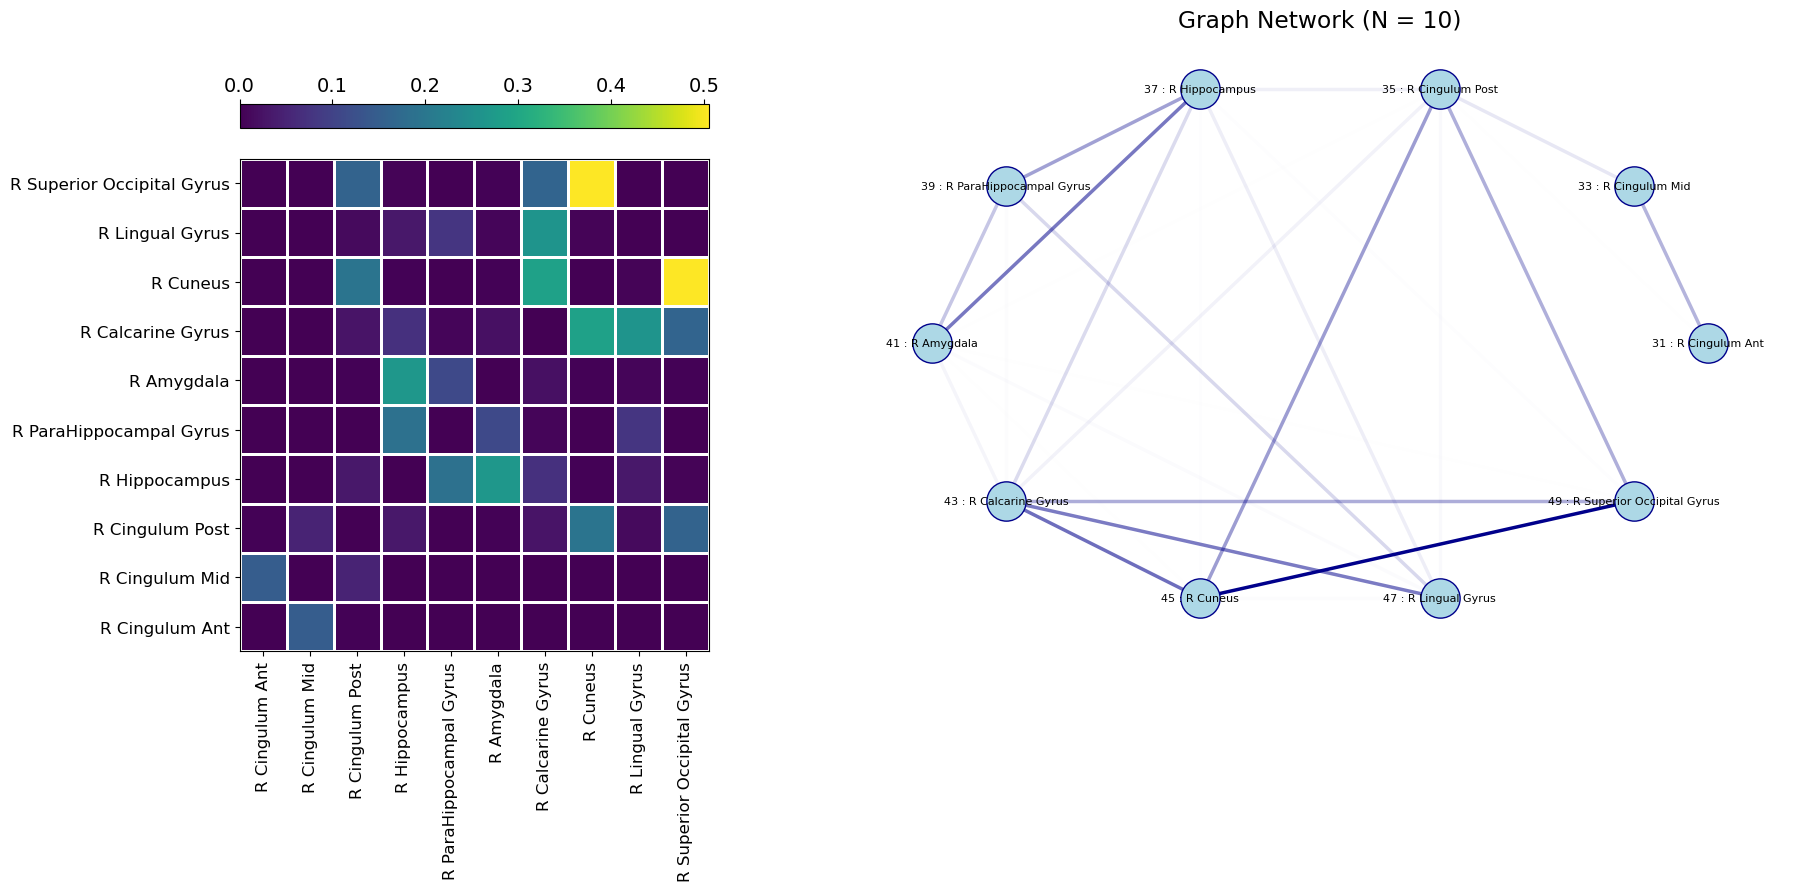

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios':[1, 2]})
pcol = axs[0].pcolormesh(ASubgraph, edgecolor='w')
axs[0].set_xticks((RandomROIS - RandomROIS[0])//2 + 0.5, RandomROI_tags, rotation=90, fontsize=12)
axs[0].set_yticks((RandomROIS - RandomROIS[0])//2 + 0.5, RandomROI_tags, fontsize=12)
fig.colorbar(pcol, ax = axs[0], location='top')


G = nx.from_numpy_array(ASubgraph, parallel_edges=False)
pos = nx.circular_layout(G) 
nx.draw_networkx_nodes(G, pos, ax=axs[1], node_color='lightblue', edgecolors='darkblue', node_size=800)

# Adding labels to the nodes
labels = {}
for n in range(nNodes):
    labels[n] = f"{RandomROIS[n]:02d} : {RandomROI_tags[n]}"
nx.draw_networkx_labels(G, pos,labels, ax=axs[1], font_size=8)

all_weights = []
#4 a. Iterate through the graph nodes to gather all the weights
for (node1, node2, data) in G.edges(data = True):
    all_weights.append(data['weight']) 

#4 b. Get unique weights
unique_weights = list(set(all_weights))
maxWeight = np.max(unique_weights)

#4 c. Plot the edges - one by one!
for weight in unique_weights:
    #4 d. Form a filtered list with just the weight you want to draw
    weighted_edges = [(node1,node2) for (node1,node2,edge_attr) in G.edges(data=True) if edge_attr['weight']==weight]
    nx.draw_networkx_edges(G, pos, ax=axs[1], edge_color='darkblue', alpha = weight / maxWeight, edgelist = weighted_edges, width = 2.5)

#Plot the graph
axs[1].axis('off')
axs[1].set_title(f"Graph Network (N = {nNodes})")

In [8]:
Dnet= np.zeros((nNodes, 2 * nNodes))

for n in range(nNodes):
    Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

In [9]:
params['Abar'] = Abar = (Dnet.T @ ASubgraph) @ Dnet

tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
params['W'] = W = np.kron(np.eye(nNodes), w)

ibias = np.array([params['i_ebias'], params['i_ibias']])
params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

In [10]:
# Initialization
random.seed(0)
xInit = np.random.uniform(minval, maxval, (nTrials, 2 * nNodes))

In [11]:
save_root = "./results/FC"
setup = "setupA"

save_str = datetime.datetime(2024, 3, 20)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

save_dir = os.path.join(save_root, setup, sub_dir)
os.makedirs(save_dir, exist_ok=True)

In [12]:
# Setting variables
window_size = 1000
overlap = 1000

params['Kglob'] = 0.8
params['i_mod'] = 0.5 / params['gamma']
modNodes = [3]

if setup == 'setupB' or setup == 'setupD':
    modNodes = [3, 4, 5]
    
sig_perm = np.array([[2.5, 4.4], [7.5, 4.4], [16.5, 4.4], [2.5, 10.5], [7.5, 10.5], [16.5, 10.5], [2.5, 16.5], [7.5, 16.5], [16.5, 16.5]])

In [13]:
%%capture

for ns, (sige, sigi) in enumerate(sig_perm):
    print(f"Evaluating {ns + 1} / {len(sig_perm)} --> sigma = [{sige:.3f}, {sigi:.3f}]^T")
    sigma = np.ones(2 * nNodes)
    sigma[0::2] = sige
    sigma[1::2] = sigi 

    if setup == 'setupC' or setup == 'setupD':
        for node in modNodes:
            sigma[2 * node] = 2.5
            sigma[2 * node + 1] = 4.4

    params['sigma'] = sigma

    fileName = f"sige_{params['sigma'][0]:.3f}_sigi_{params['sigma'][1]:.3f}_Imod_{params['i_mod']:.3f}mV_KGlob_{params['Kglob']:.2f}.pkl"

    if os.path.isfile(os.path.join(save_dir, fileName)):
        print("File found! --> Skipping calculations!")
        continue

    fucntional_connectivity = {
                                'DCOR': [],
                                'CORCOEF': [],
                                'PLV_LOW': [],
                                'PLV_HIGH': [],
                                'PLI': [],
                                'COHERENCE_LOW': [],
                                'COHERENCE_HIGH': [],
                                'ICOHERENCE': []
    }

    u = np.zeros((nTrials, 2 * nNodes, T))
    u = euler_intergrate(u, xInit, modNodes = modNodes, **params)

    for t in range(t_start, T - t_start, overlap):
        ut = np.mean(u[:, 0:: 2, t : t + window_size], axis=0)
        fucntional_connectivity['DCOR'].append(dcor_connectivity(nNodes, ut)[0])
        fucntional_connectivity['CORCOEF'].append(ccf_connectivity(nNodes, ut)[0])
        fucntional_connectivity['PLV_HIGH'].append(plv_connectivity(nNodes, filteration(ut, 80, 140, 1000))[0])
        fucntional_connectivity['PLV_LOW'].append(plv_connectivity(nNodes, filteration(ut, 40, 80, 1000))[0])
        fucntional_connectivity['PLI'].append(pli_connectivity(nNodes, ut)[0])
        fucntional_connectivity['COHERENCE_HIGH'].append(coh_connectivity(nNodes, ut, f_min = 80, f_max = 140, fs = 1000)[0])
        fucntional_connectivity['COHERENCE_LOW'].append(coh_connectivity(nNodes, ut, f_min = 40, f_max = 80, fs = 1000)[0])
        fucntional_connectivity['ICOHERENCE'].append(icoh_connectivity(nNodes, ut, f_min = 80, f_max = 140, fs = 1000)[0])

    for key, value in fucntional_connectivity.items():
        fucntional_connectivity[key] = np.array(value)

    pickle.dump(fucntional_connectivity, open(os.path.join(save_dir, fileName), 'wb'))

    for measure, FCMat in fucntional_connectivity.items():
        if measure == 'ICOHERENCE':
            continue
        FCProgressPlot(corrMat=FCMat, ROI_num=RandomROIS, corr_type=measure, SaveDir=save_dir, ifSave=True, figsize=(35, 5), **params)

In [14]:
plt.figure(figsize=(20, 4))
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))

for n in range(nNodes):
    plt.plot(time_[:-t_start], np.mean(u[:, 2 * n, t_start :], axis=0) - 10 * n, label=f"ROI :: {n} -- {RandomROI_tags[n]}")

plt.legend()

In [15]:
# _, p = sp.stats.ttest_1samp(DCOR_FC, 0.0)
# plt.figure(figsize=(10, 4))
# plt.subplot(121), plt.imshow(ASubgraph, cmap='hot_r', interpolation='none')
# plt.subplot(122), plt.imshow(np.log10(p)*(p < 0.05), vmax=0, cmap='hot_r', interpolation='none');
# plt.colorbar()
# plt.show()

In [16]:
# _, p = sp.stats.ttest_1samp(COR_FC, 0.0)

# plt.figure(figsize=(10, 4))
# plt.subplot(121), plt.imshow(ASubgraph, cmap='hot_r', interpolation='none')
# plt.subplot(122), plt.imshow(np.log10(p)*(p < 0.05), vmax=0,  cmap='hot_r', interpolation='none');
# plt.colorbar()
# plt.show()